# Вычислительные эксперименты по определению качества алгоритмов поиска лучшего узла

In [1]:
import numpy as np
import pandas as pd
import osmnx as ox
from tabulate import tabulate

import logging as lg
lg.basicConfig(level=lg.ERROR)

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time
from genesis.swiss_knife import msfpl
from genesis.tools import Progressbar

import random
import time

In [2]:
# Загрузка графа
G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


## Стратегия уменьшения максимального времени следования

Требуется найти такой узел для которого метрика max_time будет минимальной, т.е. классическая задача поиска центра графа

Лучший узел:	[4116049991]	17.03619171428572	t=618.79 сек.############################################| 100.0%



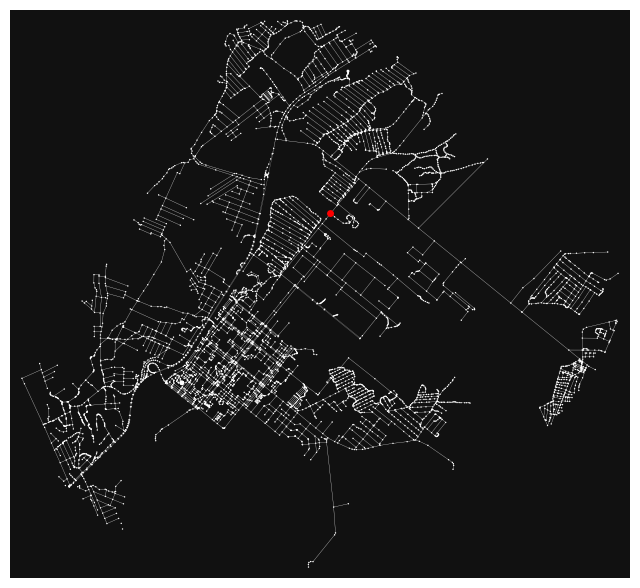

Тесты bnd:
|    | method   | strategy          |   best_node |   best_val |   calc_time |
|---:|:---------|:------------------|------------:|-----------:|------------:|
|  0 | bnf      | снижение max_time |  4116049991 |    17.0362 |      618.79 |
|  1 | bnd      | снижение max_time |  4116049991 |    17.0362 |        3.12 |
|  2 | bnd      | снижение max_time |  4116049991 |    17.0362 |        5.92 |
|  3 | bnd      | снижение max_time |  4116049991 |    17.0362 |       14.89 |
|  4 | bnd      | снижение max_time |  4116049991 |    17.0362 |       18    |
|  5 | bnd      | снижение max_time |  4116049991 |    17.0362 |        9.71 |
|  6 | bnd      | снижение max_time |  2034401823 |    17.9176 |        6.3  |
|  7 | bnd      | снижение max_time |  4116049991 |    17.0362 |        7.1  |
|  8 | bnd      | снижение max_time |  4116049991 |    17.0362 |       14.11 |
|  9 | bnd      | снижение max_time |  4116049991 |    17.0362 |        2.93 |
| 10 | bnd      | снижение max_time |  41

In [17]:
# набор данных для хранения итогов экспериментов
results={}
i=0

# Оценка лучшего узла полным перебором
start_time=time.time()
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.max,
                            )
best_node, best_val = Graphs.get_best_nodes_full(G, 
                          node_metric_function=calc_node_metric_function,
                          event_after_node_calc=Progressbar(G.number_of_nodes(), bins=100)
                          )
end_time=time.time()
print('Лучший узел:', best_node, best_val, f't={round(end_time-start_time,2)} сек.', sep='\t', end='\n\n')
results[i]={}
results[i]['method'] = 'bnf'
results[i]['strategy'] = 'снижение max_time'
results[i]['best_node'] = best_node[0]
results[i]['best_val'] = best_val
results[i]['calc_time'] = round(end_time-start_time,2)
nc = ['r' if nd==best_node[0] else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node[0] else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)


# Оценка лучшего узла стоком
experimets_count = 40
start_nodes = random.sample(list(G.nodes()), experimets_count)
print('Тесты bnd:')
pb = Progressbar(experimets_count, bins=20)
for node in start_nodes:
    i+=1
    start_time=time.time()
    best_node, best_val = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function,
                          start_node = node
                          )
    end_time=time.time()
    pb()
    # print(f'тест № {i}', best_node, best_val, f't={round(end_time-start_time,2)} сек.')
    results[i]={}
    results[i]['method'] = 'bnd'
    results[i]['strategy'] = 'снижение max_time'
    results[i]['best_node'] = best_node
    results[i]['best_val'] = best_val
    results[i]['calc_time'] = round(end_time-start_time,2)

# Вывод итога вычислений:
results = pd.DataFrame(results).T
results['best_node'] = results['best_node'].astype('int64')
print(
    tabulate(results, headers=results.columns, tablefmt='pipe'),
    end='\n\n'
)
print(': Результаты экспериментов по оценке качества алгоритмов определения лучшего узла для стратегии "минимизация максимального времени прибытия"')

## Стратегия уменьшения среднего времени следования

Требуется найти такой узел для которого метрика mean_time будет минимальной.

Лучший узел:	[426923808]	7.355415617070702	t=591.06 сек.#############################################| 100.0%



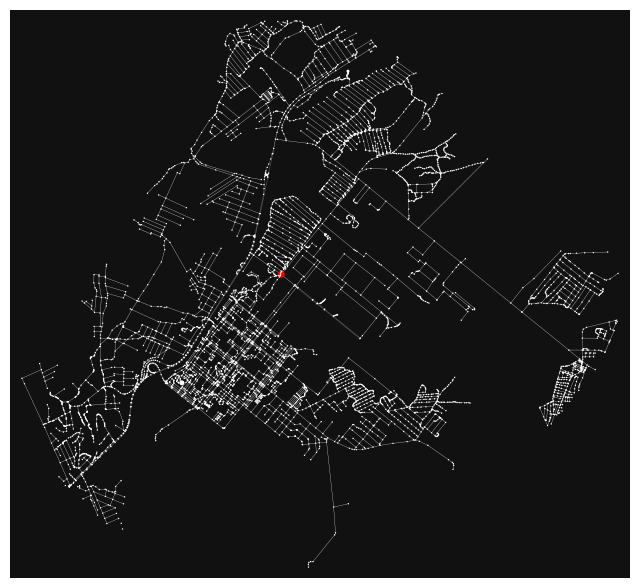

Тесты bnd:
Тесты bnd_max_mean:######################| 100.0%


ValueError: Указанный стартовый узел неприемлем, в связи с его слабой связностью с остальной частью графа

In [18]:
# набор данных для хранения итогов экспериментов
results = {}
i=0

# Оценка лучшего узла полным перебором
start_time=time.time()
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val = Graphs.get_best_nodes_full(G, 
                          node_metric_function=calc_node_metric_function,
                          event_after_node_calc=Progressbar(G.number_of_nodes(), bins=100)
                          )
end_time=time.time()
print('Лучший узел:', best_node, best_val, f't={round(end_time-start_time,2)} сек.', sep='\t', end='\n\n')
results[i]={}
results[i]['method'] = 'bnf'
results[i]['strategy'] = 'снижение mean_time'
results[i]['best_node'] = best_node[0]
results[i]['best_val'] = best_val
results[i]['calc_time'] = round(end_time-start_time,2)
nc = ['r' if nd==best_node[0] else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node[0] else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)


# Оценка лучшего узла стоком
experimets_count = 40
start_nodes = random.sample(list(G.nodes()), experimets_count)
print('Тесты bnd:')
pb = Progressbar(experimets_count, bins=experimets_count)
for node in start_nodes:
    i+=1
    start_time=time.time()
    best_node, best_val = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function,
                          start_node = node
                          )
    end_time=time.time()
    # print(f'тест № {i}', best_node, best_val, f't={round(end_time-start_time,2)} сек.')
    pb()
    results[i]={}
    results[i]['method'] = 'bnd'
    results[i]['strategy'] = 'снижение mean_time'
    results[i]['best_node'] = best_node
    results[i]['best_val'] = best_val
    results[i]['calc_time'] = round(end_time-start_time,2)


# Оценка лучшего узла стоком max+mean
experimets_count = 40
start_nodes = random.sample(list(G.nodes()), experimets_count)
print('Тесты bnd_max_mean:')
pb = Progressbar(G.number_of_nodes(), bins=experimets_count)
for node in start_nodes:
    i+=1
    start_time=time.time()
    best_node, best_val = Graphs.get_best_node_drain_max_mean(G, 
                          path_function=msfpl,
                          start_node = node
                          )
    end_time=time.time()
    # print(f'тест № {i}', best_node, best_val, f't={round(end_time-start_time,2)} сек.')
    pb()
    results[i]={}
    results[i]['method'] = 'bnd_max_mean'
    results[i]['strategy'] = 'снижение mean_time'
    results[i]['best_node'] = best_node
    results[i]['best_val'] = best_val
    results[i]['calc_time'] = round(end_time-start_time,2)

# Вывод итога вычислений:
results = pd.DataFrame(results).T
results['best_node'] = results['best_node'].astype('int64')
print(
    tabulate(results, headers=results.columns, tablefmt='pipe'),
    end='\n\n'
)
print(': Результаты экспериментов по оценке качества алгоритмов определения лучшего узла для стратегии "минимизация среднего времени прибытия"')